In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

TASK-1   DATA LOADING AND EXPLORATION

In [119]:


url = "https://raw.githubusercontent.com/SANTHIYAKARUPPANAN/Datasets/main/WA_Fn-UseC_-HR-Employee-Attrition.csv"

df = pd.read_csv(url)

Displaying Top 10 Rows of Dataset

In [6]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


Identify the target column (Attrition — Yes/No)

target column is "Attrition"

In [7]:
df["target"]=df["Attrition"]
df=df.drop("Attrition",axis=1)

Total number of rows

In [8]:
df["target"].count()

np.int64(1470)

Total Rows=1470

Total number of columns

In [9]:
len(df.columns)

35

total columns=36

Count how many employees left vs stayed and calculate the attrition rate as a  percentage

In [10]:
stayed_count=df["target"].where(df["target"]=="Yes").count()
print(stayed_count)

237


In [11]:
leave_count=df["target"].where(df["target"]=="No").count()
print(leave_count)

1233


In [12]:
stayed_ratio=(stayed_count/(stayed_count+leave_count))*100
print(stayed_ratio)

16.122448979591837


In [13]:
left_ratio=(leave_count/(stayed_count+leave_count))*100
print(left_ratio)

83.87755102040816


 Identify how many columns are numeric vs categorical

In [14]:
numeric_count=df.select_dtypes(include='number').columns
print(len(numeric_count))

26


Total number of numeric columns=26

In [15]:
categorical_count=df.select_dtypes(include='object').columns
print(len(categorical_count))


9


Total number of categorical count=10

what do you notice about the attrition rate — is it balanced or
imbalanced?

It is imbalanced.
The dataset shows that the employee attrition ratio is higher than the retention ratio. This indicates that multiple factors within the organization may be influencing employees' decisions to leave.

  TASK-2 DATA CLEANING AND PREPROCESSING

Check for missing/null values

In [16]:
df.isnull().sum()

,0
Age,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0
EnvironmentSatisfaction,0


Clearly,there is no null value in each columns

Drop the columns that add no value to prediction

In [17]:
df=df.drop(columns=["Over18","EmployeeNumber","StandardHours","EmployeeCount"],axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   BusinessTravel            1470 non-null   object
 2   DailyRate                 1470 non-null   int64 
 3   Department                1470 non-null   object
 4   DistanceFromHome          1470 non-null   int64 
 5   Education                 1470 non-null   int64 
 6   EducationField            1470 non-null   object
 7   EnvironmentSatisfaction   1470 non-null   int64 
 8   Gender                    1470 non-null   object
 9   HourlyRate                1470 non-null   int64 
 10  JobInvolvement            1470 non-null   int64 
 11  JobLevel                  1470 non-null   int64 
 12  JobRole                   1470 non-null   object
 13  JobSatisfaction           1470 non-null   int64 
 14  MaritalStatus           

Convert the target column Attrition from Yes/No to 1/0

In [18]:
df["target"]=df["target"].map({'Yes':1,'No':0})
df["target"]

,target
0,1
1,0
2,1
3,0
4,0
...,...
1465,0
1466,0
1467,0
1468,0


Encode all remaining categorical columns using One-Hot Encoding (e.g.,
Department, JobRole, MaritalStatus, BusinessTravel)

In [19]:
categorical_columns=df.select_dtypes(include="object").columns
print(categorical_columns)

Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime'],
      dtype='object')


In [121]:
df=pd.get_dummies(df,columns=["BusinessTravel"],drop_first=True)

In [50]:
df=pd.get_dummies(df,columns=["Department","EducationField","Gender","JobRole","MaritalStatus"],drop_first=True)

In [22]:
df["OverTime"]=df["OverTime"].map({'Yes':1,'No':0})

Scale numeric features using StandardScaler

In [51]:
numeric_columns=df.select_dtypes(include="int64").columns
print(numeric_columns)

Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education',
       'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel',
       'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears',
       'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany',
       'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')


In [52]:
continuous_cols = [
    'Age',
    'DailyRate',
    'DistanceFromHome',
    'HourlyRate',
    'MonthlyIncome',
    'MonthlyRate',
    'NumCompaniesWorked',
    'PercentSalaryHike',
    'TotalWorkingYears',
    'TrainingTimesLastYear',
    'YearsAtCompany',
    'YearsInCurrentRole',
    'YearsSinceLastPromotion',
    'YearsWithCurrManager'
]

In [53]:
from sklearn.model_selection import train_test_split
y=df["target"]
x=df.drop("target",axis=1)

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train[continuous_cols] = scaler.fit_transform(x_train[continuous_cols])

x_test[continuous_cols] = scaler.transform(x_test[continuous_cols])

In [54]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1176 entries, 1097 to 1126
Data columns (total 44 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                1176 non-null   float64
 1   DailyRate                          1176 non-null   float64
 2   DistanceFromHome                   1176 non-null   float64
 3   Education                          1176 non-null   int64  
 4   EnvironmentSatisfaction            1176 non-null   int64  
 5   HourlyRate                         1176 non-null   float64
 6   JobInvolvement                     1176 non-null   int64  
 7   JobLevel                           1176 non-null   int64  
 8   JobSatisfaction                    1176 non-null   int64  
 9   MonthlyIncome                      1176 non-null   float64
 10  MonthlyRate                        1176 non-null   float64
 11  NumCompaniesWorked                 1176 non-null   float64

In [55]:
x_train.head()

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
1097,-1.388559,-1.108139,1.440396,2,3,-0.472832,2,1,1,-0.868277,...,False,True,False,False,False,False,False,False,False,False
727,-2.040738,-1.263481,-0.522699,2,2,0.309374,3,1,4,-1.132807,...,False,False,False,False,False,True,False,False,False,True
254,-0.845077,1.103647,1.317703,2,4,-1.059487,3,2,4,0.116537,...,False,False,False,False,False,False,True,False,False,False
1175,0.241886,-0.758001,0.336155,3,4,-0.032841,3,2,2,-0.231070,...,False,False,False,True,False,False,False,False,True,False
1341,-0.627685,-1.204303,1.317703,3,2,1.091580,3,2,3,-0.464366,...,False,True,False,False,False,False,False,False,False,False


Task 3 — Exploratory Data Analysis — EDA

Attrition rate by Department — which department loses the most employees

In [27]:
df["Department"].unique()

array(['Sales', 'Research & Development', 'Human Resources'], dtype=object)

In [28]:
sales_attrition = df[
    (df["target"] == 1) & (df["Department"] == "Sales")
]

print((len(sales_attrition)/df["target"].count())*100)

6.258503401360545


In [29]:
rad_attrition = df[(df["target"] == 1) & (df["Department"] == "Research & Development")]

print((len(rad_attrition)/df["target"].count())*100)

9.047619047619047


In [30]:
hr_attrition = df[(df["target"] == 1) & (df["Department"] == "Human Resources")]

print((len(hr_attrition)/df["target"].count())*100)

0.8163265306122449


Research and Development Department looses the most Employee.

Attrition rate by Job Role — which roles have the highest exit rate?

In [31]:
job_roles=df["JobRole"].unique()
job_roles

array(['Sales Executive', 'Research Scientist', 'Laboratory Technician',
       'Manufacturing Director', 'Healthcare Representative', 'Manager',
       'Sales Representative', 'Research Director', 'Human Resources'],
      dtype=object)

In [32]:
for i in range(len(job_roles)):
    attrition = df[
        (df["target"] == 1) &
        (df["JobRole"] == job_roles[i])
    ]

    total = len(df[df["JobRole"] == job_roles[i]])

    print(
        job_roles[i],
        "attrition rate is",
        (len(attrition) / total) * 100
    )

Sales Executive attrition rate is 17.484662576687114
Research Scientist attrition rate is 16.095890410958905
Laboratory Technician attrition rate is 23.93822393822394
Manufacturing Director attrition rate is 6.896551724137931
Healthcare Representative attrition rate is 6.870229007633588
Manager attrition rate is 4.901960784313726
Sales Representative attrition rate is 39.75903614457831
Research Director attrition rate is 2.5
Human Resources attrition rate is 23.076923076923077


Laboratory Technician has the highest exit rate

Attrition vs Monthly Income — do lower paid employees leave more?

In [33]:
df["target"]=df["target"].map({1:'Yes',0:'No'})

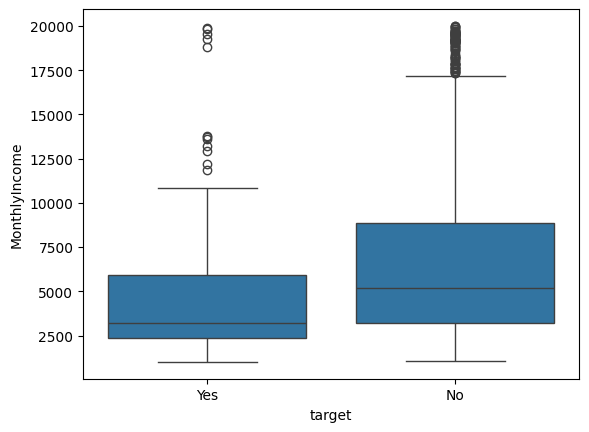

In [34]:
sns.boxplot(x="target", y="MonthlyIncome", data=df)
plt.show()

yes,Lowest Paid Employees leave more

Attrition vs Work-Life Balance rating — is there a visible pattern?

In [35]:
df["WorkLifeBalance"].unique()

array([1, 3, 2, 4])

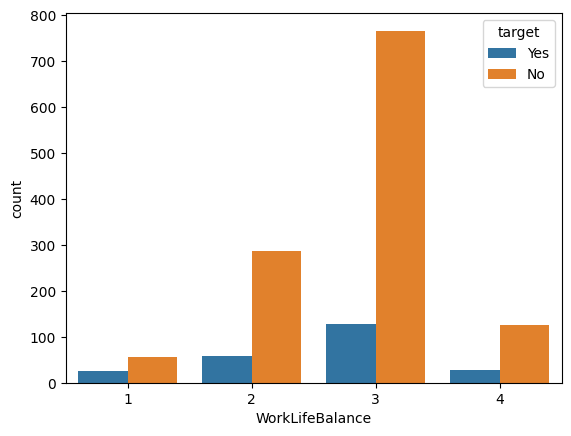

In [36]:
sns.countplot(x="WorkLifeBalance", hue="target", data=df)
plt.show()

There is no visible pattern observed.Eventhough,the worklifebalance rating given 3 has high attrition rate than rating 2

Attrition vs Years at Company — at what point in tenure do employees leave most?

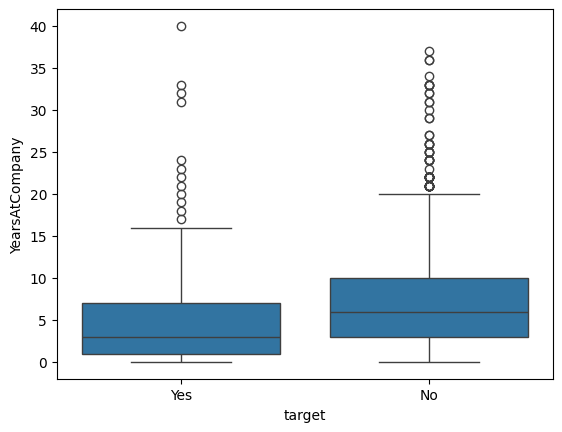

In [37]:
sns.boxplot(x="target", y="YearsAtCompany", data=df)
plt.show()

Employees with least Experience has the more exit rate (at the 5-7 years of experience).

Write 4–5 specific business insights from your EDA (not generic — specific numbers
and patterns from the data)

Task 4 — Model Building & Comparison

LogisticRegressionModel

In [56]:
print(x_train.dtypes)

Age                                  float64
DailyRate                            float64
DistanceFromHome                     float64
Education                              int64
EnvironmentSatisfaction                int64
HourlyRate                           float64
JobInvolvement                         int64
JobLevel                               int64
JobSatisfaction                        int64
MonthlyIncome                        float64
MonthlyRate                          float64
NumCompaniesWorked                   float64
OverTime                               int64
PercentSalaryHike                    float64
PerformanceRating                      int64
RelationshipSatisfaction               int64
StockOptionLevel                       int64
TotalWorkingYears                    float64
TrainingTimesLastYear                float64
WorkLifeBalance                        int64
YearsAtCompany                       float64
YearsInCurrentRole                   float64
YearsSince

In [66]:
from sklearn.linear_model import LogisticRegression

model_logistic= LogisticRegression(class_weight='balanced', random_state=42)

model_logistic.fit(x_train, y_train)

LogisticRegression(class_weight='balanced', random_state=42)

RandomForestClassifierModel

In [58]:
from sklearn.ensemble import RandomForestClassifier

model_random= RandomForestClassifier(class_weight='balanced', random_state=42)

model_random.fit(x_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

GrdientBoostingClassifierModel

In [59]:
pip install imbalanced-learn

In [60]:
from imblearn.over_sampling import SMOTE

In [61]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)

In [62]:
print(y_train.value_counts())

target
No     978
Yes    198
Name: count, dtype: int64


In [63]:
print(y_train_smote.value_counts())

target
No     978
Yes    978
Name: count, dtype: int64


In [64]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb.fit(X_train_smote, y_train_smote)

GradientBoostingClassifier(random_state=42)

Task 5 — Model Evaluation

Evaluate all 3 models

LogisticRegression

In [83]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_auc_score
)

lr_predict = model_logistic.predict(x_test)
lr_prob = model_logistic.predict_proba(x_test)[:,1]

print("Accuracy :", accuracy_score(y_test, lr_predict))
print("Confusion Matrix:\n", confusion_matrix(y_test, lr_predict))
print("Precision :", precision_score(y_test, lr_predict, pos_label="Yes"))
print("Recall :", recall_score(y_test, lr_predict, pos_label="Yes"))
print("F1 Score :", f1_score(y_test, lr_predict, pos_label="Yes"))
print("classification_report: ",classification_report(y_test, lr_predict))
print("ROC-AUC:", roc_auc_score(y_test, lr_prob))

Accuracy : 0.7142857142857143
Confusion Matrix:
 [[188  67]
 [ 17  22]]
Precision : 0.24719101123595505
Recall : 0.5641025641025641
F1 Score : 0.34375
classification_report:                precision    recall  f1-score   support

          No       0.92      0.74      0.82       255
         Yes       0.25      0.56      0.34        39

    accuracy                           0.71       294
   macro avg       0.58      0.65      0.58       294
weighted avg       0.83      0.71      0.75       294

ROC-AUC: 0.7710407239819005


RandomForest

In [84]:
rf_predict=model_random.predict(x_test)
rf_prob=model_random.predict_proba(x_test)[:,1]

print("Accuracy :", accuracy_score(y_test, rf_predict))
print("Confusion Matrix:\n", confusion_matrix(y_test, rf_predict))
print("Precision :", precision_score(y_test, rf_predict, pos_label="Yes"))
print("Recall :", recall_score(y_test, rf_predict, pos_label="Yes"))
print("F1 Score :", f1_score(y_test, rf_predict, pos_label="Yes"))
print("classification_report: ",classification_report(y_test, rf_predict))
print("ROC-AUC:", roc_auc_score(y_test, rf_prob))

Accuracy : 0.8775510204081632
Confusion Matrix:
 [[254   1]
 [ 35   4]]
Precision : 0.8
Recall : 0.10256410256410256
F1 Score : 0.18181818181818182
classification_report:                precision    recall  f1-score   support

          No       0.88      1.00      0.93       255
         Yes       0.80      0.10      0.18        39

    accuracy                           0.88       294
   macro avg       0.84      0.55      0.56       294
weighted avg       0.87      0.88      0.83       294

ROC-AUC: 0.749069884364002


GradientBoosting

In [85]:
gb_predict=gb.predict(x_test)
gb_prob=gb.predict_proba(x_test)[:,1]

print("Accuracy :", accuracy_score(y_test, gb_predict))
print("Confusion Matrix:\n", confusion_matrix(y_test, gb_predict))
print("Precision :", precision_score(y_test, gb_predict, pos_label="Yes"))
print("Recall :", recall_score(y_test, gb_predict, pos_label="Yes"))
print("F1 Score :", f1_score(y_test, gb_predict, pos_label="Yes"))
print("classification_report: ",classification_report(y_test, gb_predict))
print("ROC-AUC:", roc_auc_score(y_test, gb_prob))

Accuracy : 0.8673469387755102
Confusion Matrix:
 [[243  12]
 [ 27  12]]
Precision : 0.5
Recall : 0.3076923076923077
F1 Score : 0.38095238095238093
classification_report:                precision    recall  f1-score   support

          No       0.90      0.95      0.93       255
         Yes       0.50      0.31      0.38        39

    accuracy                           0.87       294
   macro avg       0.70      0.63      0.65       294
weighted avg       0.85      0.87      0.85       294

ROC-AUC: 0.7777777777777778


Comparing above three Models:
        Gradient Boosting Model perform best among the above three.

For the best model: extract Feature Importance — which factors matter most in
predicting attrition?

In [86]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": gb.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

                              Feature  Importance
16                   StockOptionLevel    0.136931
7                            JobLevel    0.088846
23               YearsWithCurrManager    0.068380
43               MaritalStatus_Single    0.062927
40            JobRole_Sales Executive    0.056356
24   BusinessTravel_Travel_Frequently    0.052376
12                           OverTime    0.043323
25       BusinessTravel_Travel_Rarely    0.042776
6                      JobInvolvement    0.035348
11                 NumCompaniesWorked    0.031721
18              TrainingTimesLastYear    0.031082
42              MaritalStatus_Married    0.028119
22            YearsSinceLastPromotion    0.027759
8                     JobSatisfaction    0.027547
33                        Gender_Male    0.023625
27                   Department_Sales    0.023338
20                     YearsAtCompany    0.022815
19                    WorkLifeBalance    0.021570
0                                 Age    0.020632


Rank the top 10 most important features driving employee exit

In [87]:
print(feature_importance.head(10))

                             Feature  Importance
16                  StockOptionLevel    0.136931
7                           JobLevel    0.088846
23              YearsWithCurrManager    0.068380
43              MaritalStatus_Single    0.062927
40           JobRole_Sales Executive    0.056356
24  BusinessTravel_Travel_Frequently    0.052376
12                          OverTime    0.043323
25      BusinessTravel_Travel_Rarely    0.042776
6                     JobInvolvement    0.035348
11                NumCompaniesWorked    0.031721


Task 6 — Visualization (Minimum 4 charts)

Chart 1: Bar chart showing attrition rate by Department and Job Role

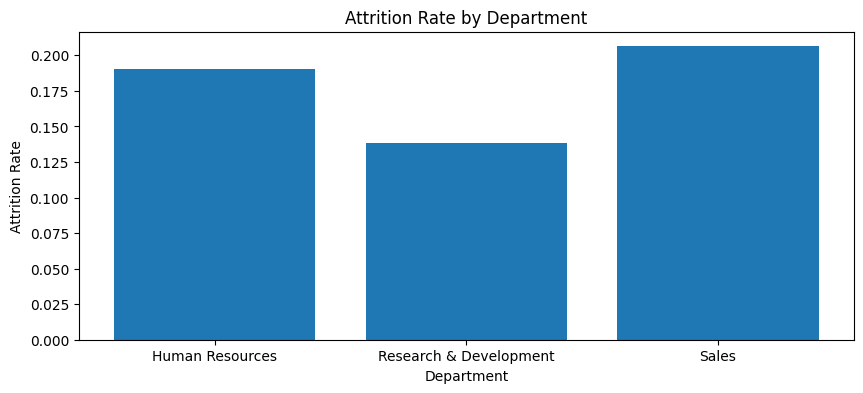

In [120]:
df_original = pd.read_csv(url)
df_original["Atttrition"] = df_original["Attrition"].map({'Yes':1,'No':0})

attrition_dept = df_original.groupby("Department")["Atttrition"].mean()

plt.figure(figsize=(10,4))
plt.bar(attrition_dept.index, attrition_dept.values)

plt.xlabel("Department")
plt.ylabel("Attrition Rate")
plt.title("Attrition Rate by Department")
plt.savefig("attrition_dept.png")

plt.show()

Chart 2: Box plot comparing Monthly Income of employees who left vs stayed

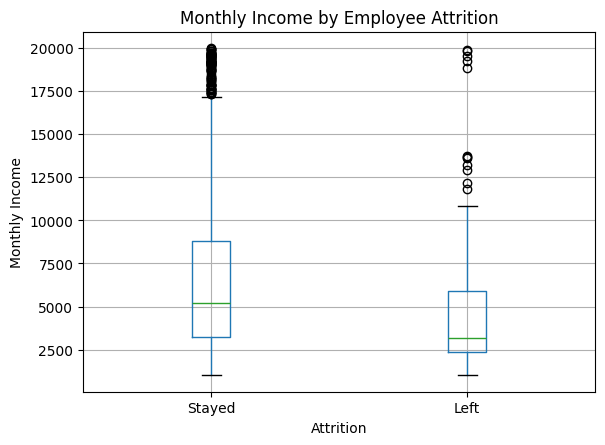

In [112]:
import matplotlib.pyplot as plt

df_original.boxplot(column="MonthlyIncome", by="Attrition")

plt.title("Monthly Income by Employee Attrition")
plt.suptitle("")   # remove automatic title

plt.xlabel("Attrition")
plt.ylabel("Monthly Income")

# Fix x-axis labels (do this BEFORE show)
plt.xticks([1, 2], ["Stayed", "Left"])

plt.savefig("monthly_income_by_attrition.png", dpi=300, bbox_inches="tight")

plt.show()

Chart 3: Confusion Matrix heatmap for your best model

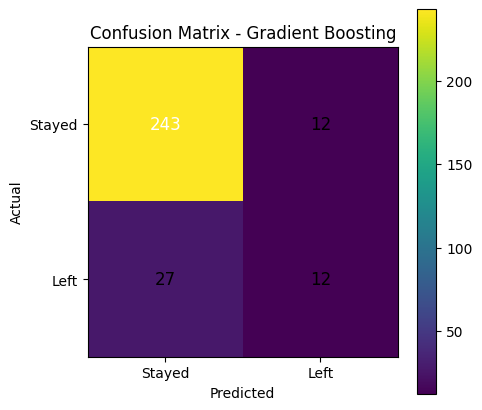

In [113]:

# Confusion Matrix
cm = confusion_matrix(y_test, gb_predict)

plt.figure(figsize=(5,5))

plt.imshow(cm)
plt.colorbar()

# Axis labels
plt.xticks([0, 1], ["Stayed", "Left"])
plt.yticks([0, 1], ["Stayed", "Left"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Gradient Boosting")

# Add numbers inside the boxes
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j],
                 ha='center',
                 va='center',
                 fontsize=12,
                 color='white' if cm[i, j] > cm.max()/2 else 'black')
        plt.savefig("confusion_matrix_gradientboosting.png")

plt.show()

Chart 4: Horizontal bar chart of Top 10 Feature Importances from your best model

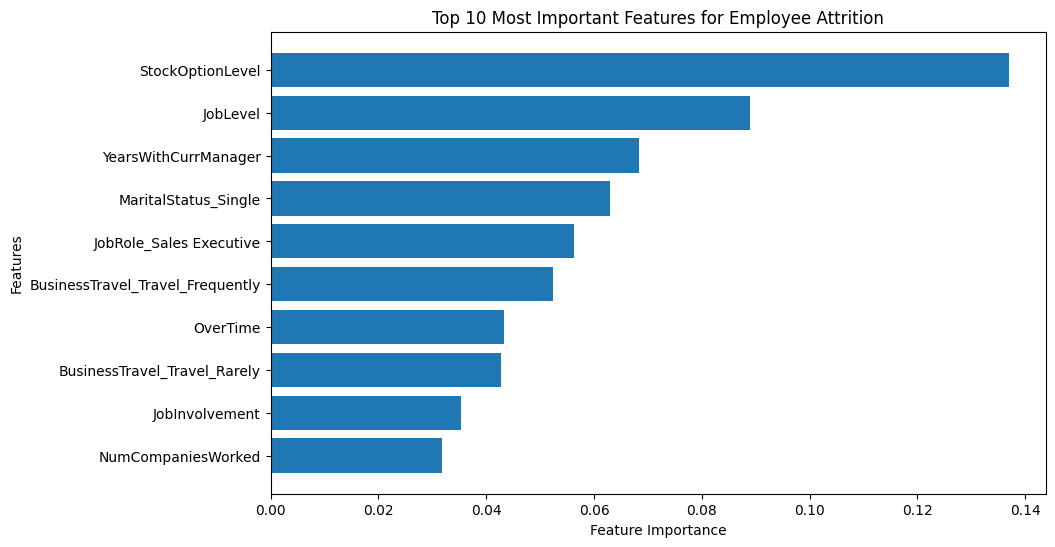

In [114]:
feature_importance = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": gb.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Select top 10
top10 = feature_importance.head(10)

# Plot
plt.figure(figsize=(10,6))
plt.barh(top10["Feature"], top10["Importance"])

plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Top 10 Most Important Features for Employee Attrition")

# Highest importance at the top
plt.gca().invert_yaxis()
plt.savefig("top10_features_gb.png")

plt.show()

Chart 5 (Bonus): ROC Curve comparing all 3 models on one graph

In [106]:
print(y_test.unique())
print(type(lr_prob))
print(len(y_test), len(lr_prob))

['No' 'Yes']
<class 'numpy.ndarray'>
294 294


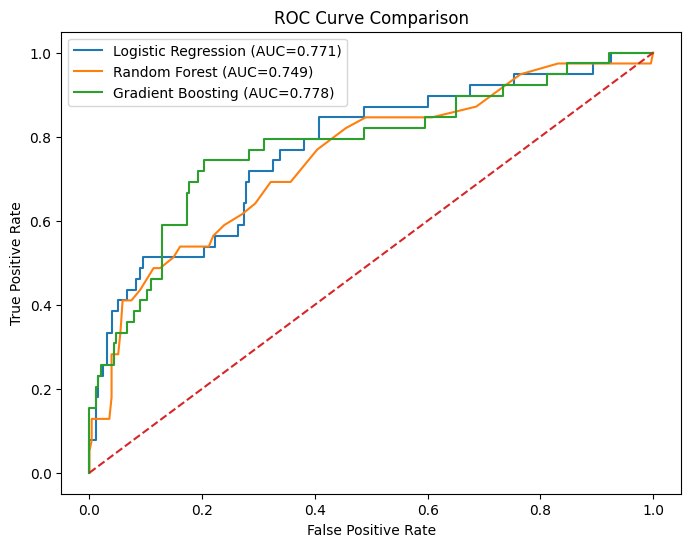

In [115]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Logistic Regression
lr_prob = model_logistic.predict_proba(x_test)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_prob, pos_label="Yes")
auc_lr = roc_auc_score(y_test, lr_prob)

# Random Forest
rf_prob = model_random.predict_proba(x_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob, pos_label="Yes")
auc_rf = roc_auc_score(y_test, rf_prob)

# Gradient Boosting
gb_prob = gb.predict_proba(x_test)[:, 1]
fpr_gb, tpr_gb, _ = roc_curve(y_test, gb_prob, pos_label="Yes")
auc_gb = roc_auc_score(y_test, gb_prob)

# Plot
plt.figure(figsize=(8,6))

plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC={auc_lr:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={auc_rf:.3f})")
plt.plot(fpr_gb, tpr_gb, label=f"Gradient Boosting (AUC={auc_gb:.3f})")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.savefig("roc_curve_comparison.png")
plt.show()

Task 7 — HR Insights & Business Recommendations

Based on the model results, the strongest predictors of employee attrition are **OverTime**, **MonthlyIncome**, and **YearsAtCompany**, indicating that workload, compensation, and employee experience significantly influence whether an employee leaves. Employees in **Sales** and roles such as **Sales Executive** show higher attrition rates, suggesting these groups should be prioritized for retention efforts. Salary alone does not fully explain attrition; while it has some impact, factors like overtime, job satisfaction, and work-life balance are stronger drivers. Based on these findings, HR can implement targeted retention strategies such as **reducing excessive overtime or offering flexible work schedules for high-risk employees**, and **conducting stay-interviews for employees in high-attrition roles like Sales Executive or frequent overtime workers**. A key limitation of this model is that it is based on historical data and cannot capture real-time personal or psychological factors, so HR decisions should combine model insights with human judgment and employee feedback.
